In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Dataset

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
def build_azimuth_bin_map(dataset, bin_width=10):
    # --- Step 1: gather azimuth values per class ---
    class_azims = defaultdict(list)
    for path, label in dataset.samples:
        az = parse_metadata(path)['azim']
        if az is not None:
            class_azims[label].append(az)

    # --- Step 2: compute bin ranges per class ---
    class_bin_info = {}
    for label, azims in class_azims.items():
        az_min = min(azims)
        az_max = max(azims)
        bin_start = (az_min // bin_width) * bin_width
        bin_end   = (az_max // bin_width) * bin_width
        bins = list(range(bin_start, bin_end + bin_width, bin_width))
        class_bin_info[label] = {
            'min'   : az_min,
            'max'   : az_max,
            'bins'  : bins,
            'n_bins': len(bins),
        }

    # --- Step 3: compute global offset per class (last class first) ---
    sorted_classes = sorted(class_bin_info.keys(), reverse=False)
    offset = {}
    cumulative = 0
    for label in sorted_classes:
        offset[label] = cumulative
        cumulative += class_bin_info[label]['n_bins']
    total_bins = cumulative

    # --- Step 4: assign each sample a global bin index ---
    sample_to_bin_idx = {}
    for sample_idx, (path, label) in enumerate(dataset.samples):
        az = parse_metadata(path)['azim']
        if az is None:
            continue
        info = class_bin_info[label]
        bin_start_for_az = (az // bin_width) * bin_width
        local_bin = (bin_start_for_az - info['bins'][0]) // bin_width
        sample_to_bin_idx[sample_idx] = offset[label] + local_bin

    # --- Step 5: build new class name list indexed by new label ---
    new_classes = [None] * total_bins
    for label in sorted_classes:
        info = class_bin_info[label]
        vehicle = dataset.classes[label]
        for local_bin, bin_lower in enumerate(info['bins']):
            new_label = offset[label] + local_bin
            new_classes[new_label] = f"{vehicle}_az{bin_lower}"

    
    new_to_old_classes = {}
    for label in sorted_classes:
        info = class_bin_info[label]
        for local_bin in range(info['n_bins']):
            new_label = offset[label] + local_bin
            new_to_old_classes[new_label] = label

    return sample_to_bin_idx, class_bin_info, total_bins, new_classes, new_to_old_classes


def print_bin_summary(class_bin_info, dataset, bin_width=10):
    print(f"{'Label':<6} {'Class':<20} {'Az range':<14} {'N_bins'}")
    print("-" * 55)
    for label in sorted(class_bin_info):
        info = class_bin_info[label]
        class_name = dataset.classes[label]
        az_range = f"{info['min']} – {info['max']}"
        print(f"{label:<6} {class_name:<20} {az_range:<14} {info['n_bins']}")
    k = len(class_bin_info)
    total = sum(v['n_bins'] for v in class_bin_info.values())
    print("-" * 55)
    print(f"k={k} classes, total bins = {total}  (= Σ N_i)")


class AzimuthBinnedDataset(Dataset):
    def __init__(self, dataset, sample_to_bin_idx, new_classes):
        self.dataset = dataset
        self.sample_to_bin_idx = sample_to_bin_idx
        self.classes = new_classes
        self.valid_indices = [i for i in range(len(dataset)) if i in sample_to_bin_idx]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        original_idx = self.valid_indices[idx]
        image, _ = self.dataset[original_idx]
        new_label = self.sample_to_bin_idx[original_idx]
        return image, new_label

    @property
    def samples(self):
        return [(self.dataset.samples[i][0], self.sample_to_bin_idx[i]) for i in self.valid_indices]

In [7]:
SSR_synth_lst = []

for _ in range(7):
    SSR_synth_ds = DatasetFolderWithPath(
        os.path.join(data_workspace, "mat_files/synth"),
        extensions = (".mat"),
        transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.8, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
        loader = mat_file_loader
    )

    SSR_synth_ds_14_15_16 = filter_by_elev(SSR_synth_ds, {14, 15, 16})
    s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(SSR_synth_ds_14_15_16, bin_width=10)
    print_bin_summary(b, SSR_synth_ds_14_15_16)
    new_SSR_synth_ds_14_15_16 = AzimuthBinnedDataset(SSR_synth_ds_14_15_16, s, new_classes)

    SSR_synth_lst.append(new_SSR_synth_ds_14_15_16)

new_SSR_synth_ds_big_14_15_16 = ConcatDataset(SSR_synth_lst)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 79        7
8      t72                  13 – 79        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)
Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35      

In [8]:
meas_ds_14_15_16 = filter_by_elev(meas_ds, {14, 15, 16})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_14_15_16, bin_width=10)
print_bin_summary(b, meas_ds_14_15_16)

new_meas_ds_14_15_16 = AzimuthBinnedDataset(meas_ds_14_15_16, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 79        7
8      t72                  13 – 79        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [9]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
print_bin_summary(b, meas_ds_17)

new_meas_ds_17 = AzimuthBinnedDataset(meas_ds_17, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 12 – 79        7
2      btr70                11 – 79        7
3      m1                   12 – 78        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 77        7
8      t72                  11 – 78        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [10]:
train_ds = new_SSR_synth_ds_big_14_15_16
valid_ds = new_meas_ds_14_15_16
test_ds  = new_meas_ds_17

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [11]:
len(train_ds), len(valid_ds), len(test_ds)

(5642, 806, 539)

In [12]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

train_loss = []
val_loss = []
train_acc =[]
val_acc = []

for i, seed in enumerate(seed_lst):
    start = time.perf_counter()
    print(f"Training Run {i}: seed {seed}")

    set_seed(seed)

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=12, pin_memory = True, persistent_workers=True, prefetch_factor=8, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=4, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=4, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    # load pre-trained model
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(test_ds.classes))
    )
    
    # Insert Dropout2d after each residual block
    dropout_rate = 0.1
    for layer in [model.layer1, model.layer2, model.layer3, model.layer4]:
        for block in layer:
            block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
            def make_forward(b, orig_fwd):
                def forward(x):
                    out = orig_fwd(x)
                    return b.block_dropout(out)
                return forward
            block.forward = make_forward(block, block.forward)

    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        "val_loss" : [],
        "train_acc": [],
        "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80_mc.pth"))

    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 3.5261995512 Acc: 0.1210563630
val Loss: 2.4966634148 Acc: 0.3039702233
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 1.6825558729 Acc: 0.4845799362
val Loss: 1.6778143653 Acc: 0.5049627792
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.9387200123 Acc: 0.6988656505
val Loss: 1.4344810561 Acc: 0.5781637717
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.6352546634 Acc: 0.7864232542
val Loss: 1.4250651472 Acc: 0.5806451613
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.4848155014 Acc: 0.8326834456
val Loss: 1.3590578635 Acc: 0.6228287841
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.3995933274 Acc: 0.8668911733
val Loss: 1.3562675845 Acc: 0.5918114144
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.3269391857 Acc: 0.8924140376
val Loss: 1.2626758593 Acc: 0.6327543424
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.3027765430 Acc: 0.8973768167
val Loss: 1.3936110831 Acc: 0.6178660050
Epoch 7 LR: 0.0002988184
Epoch 8
train

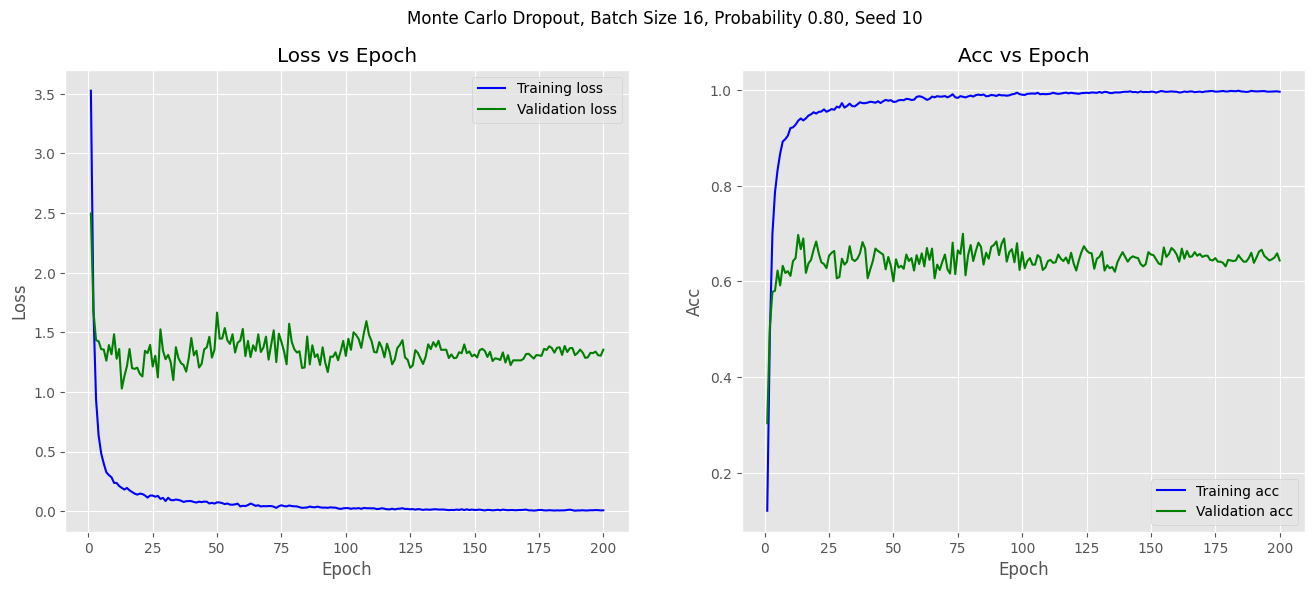

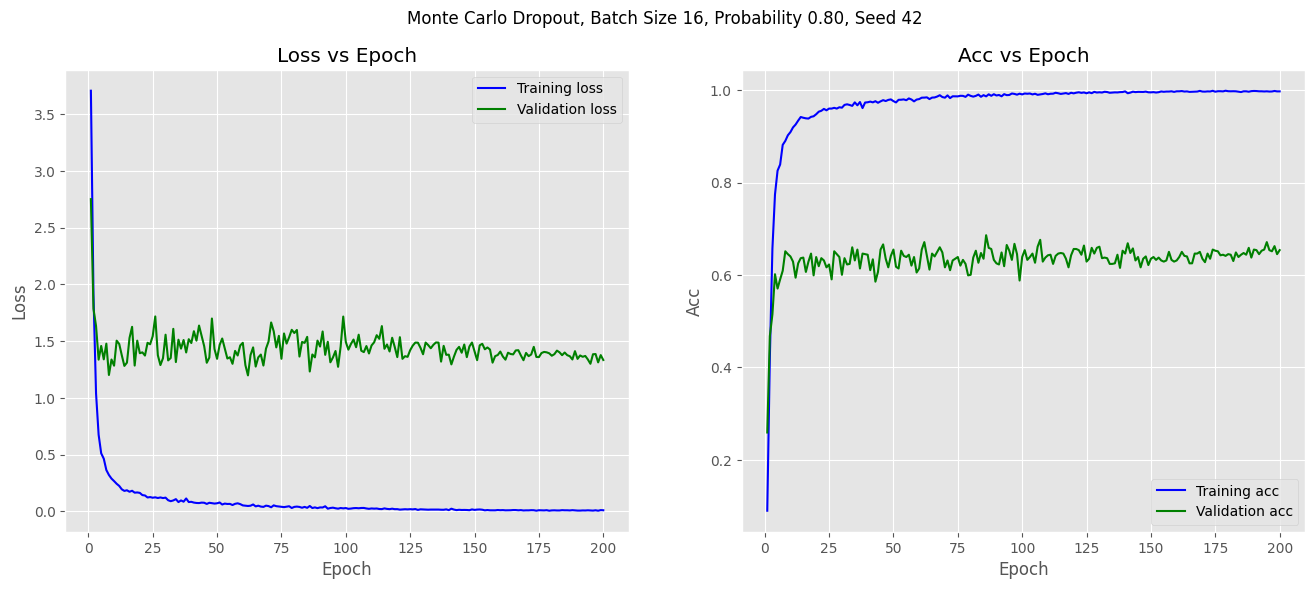

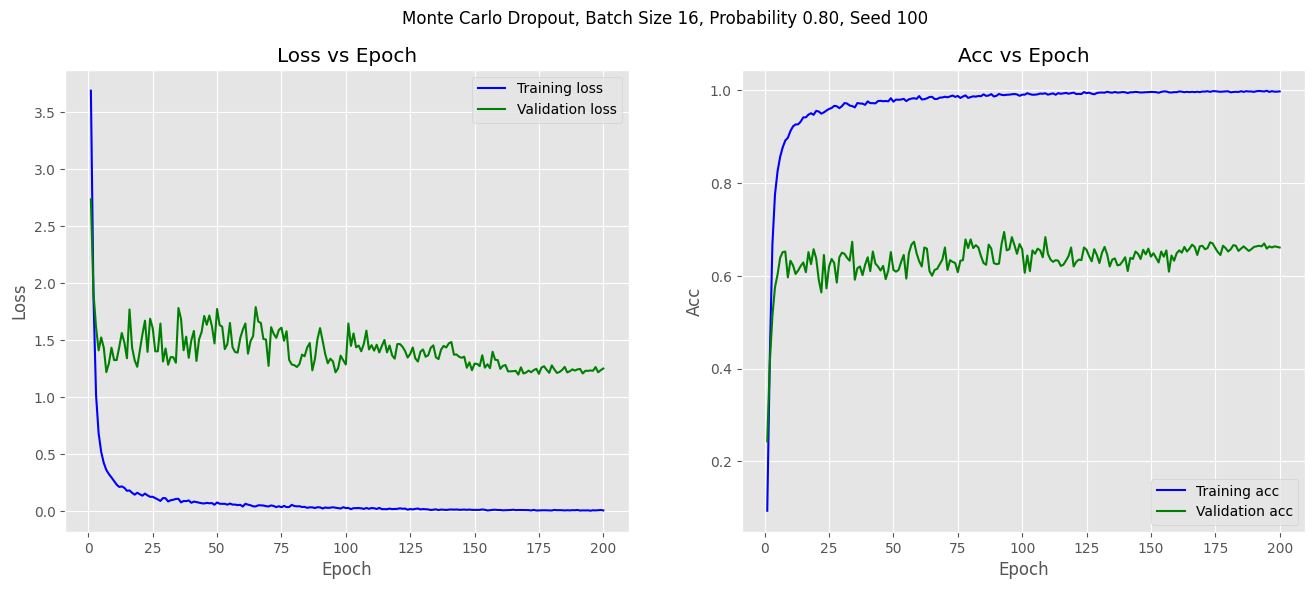

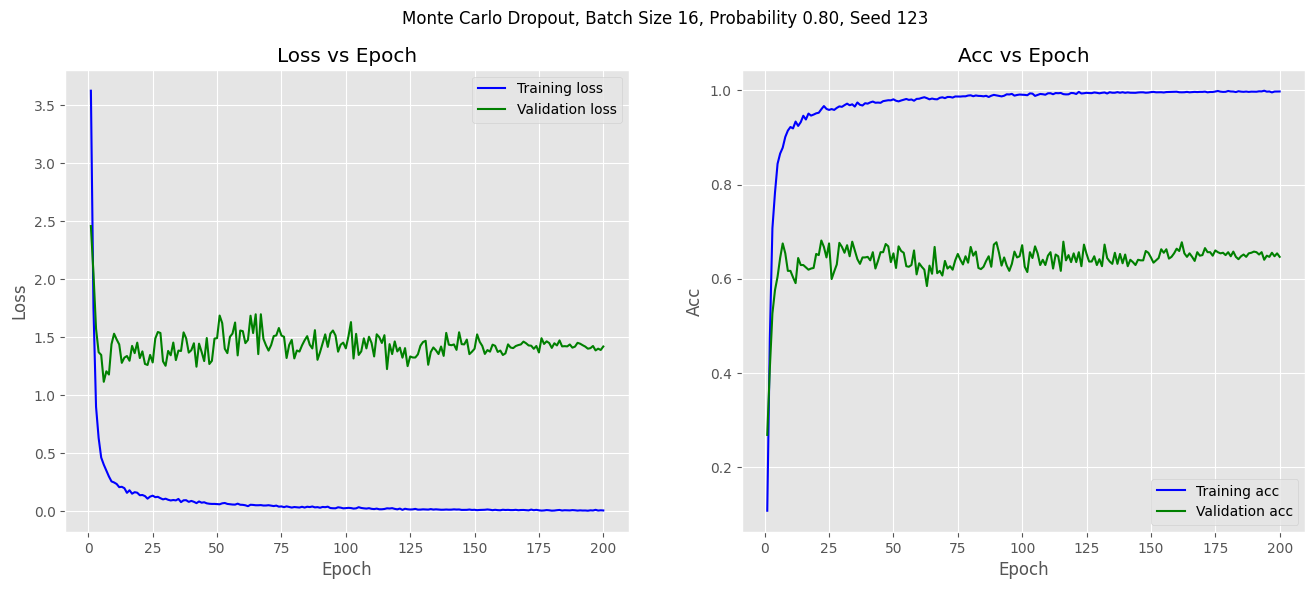

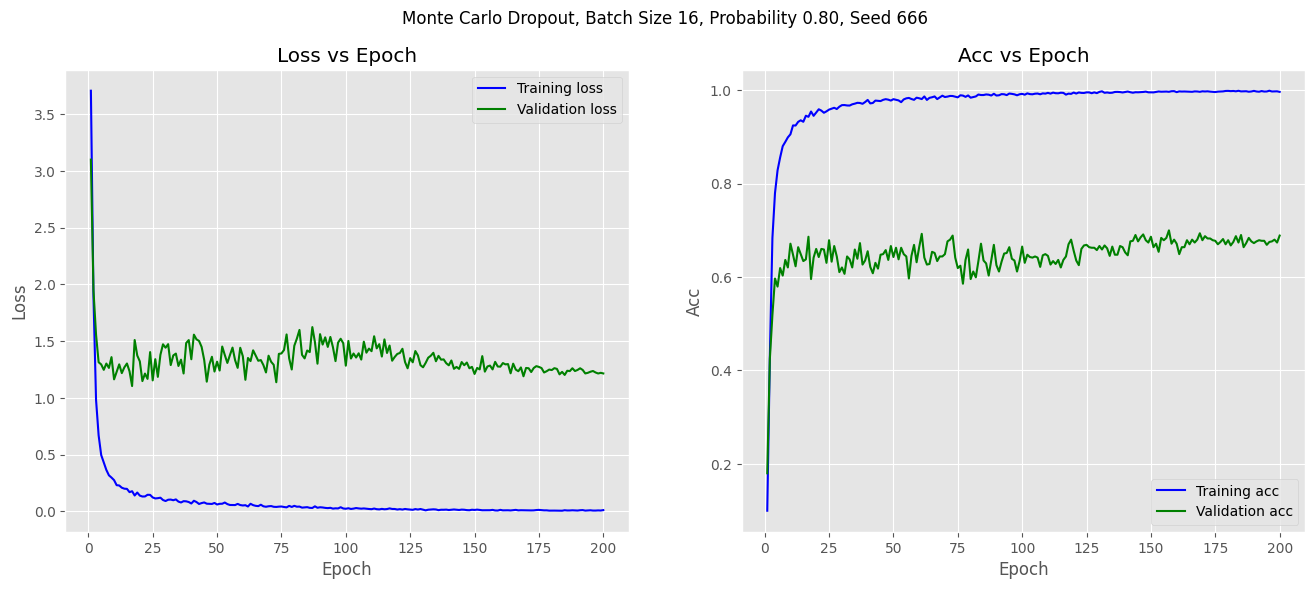

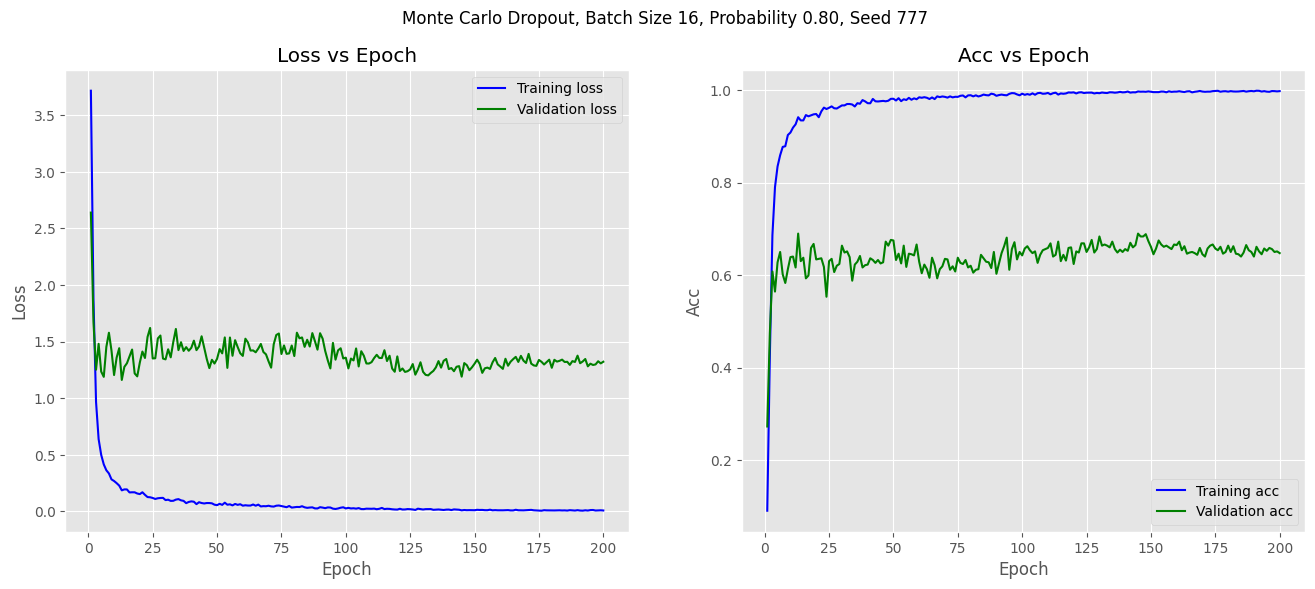

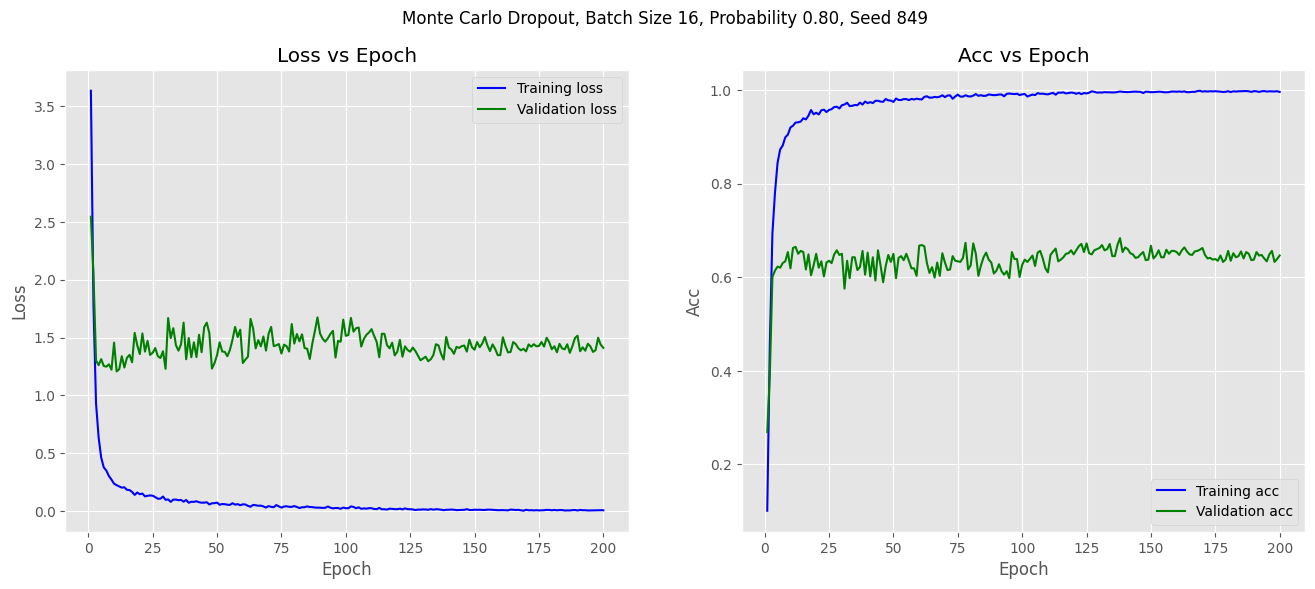

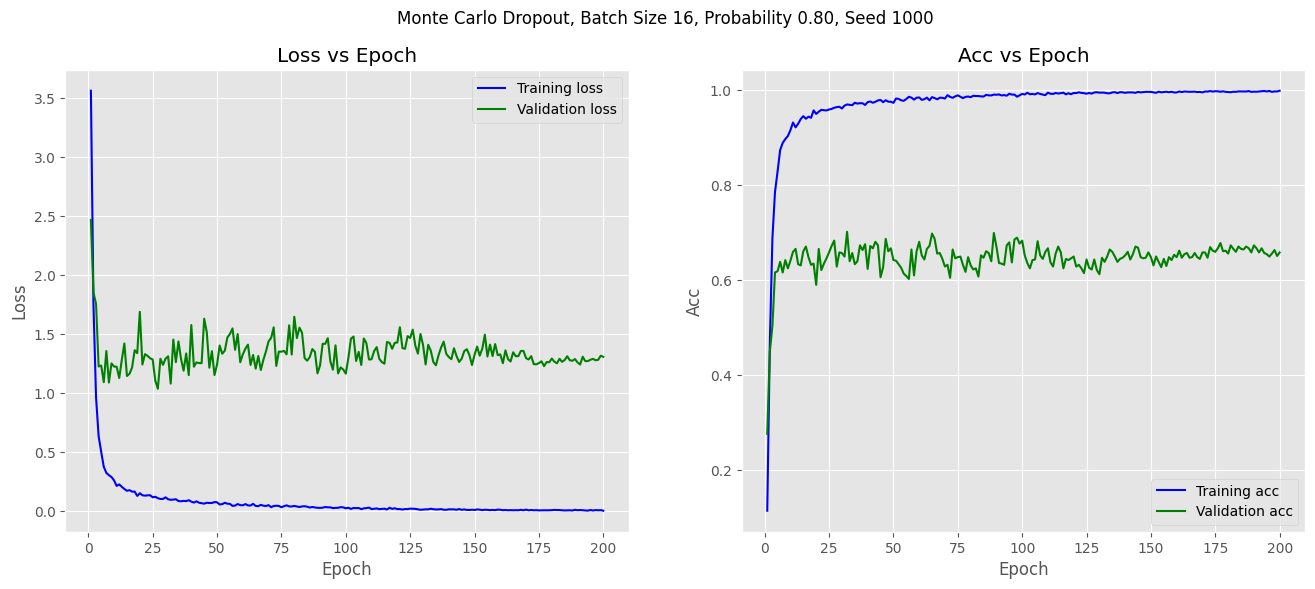

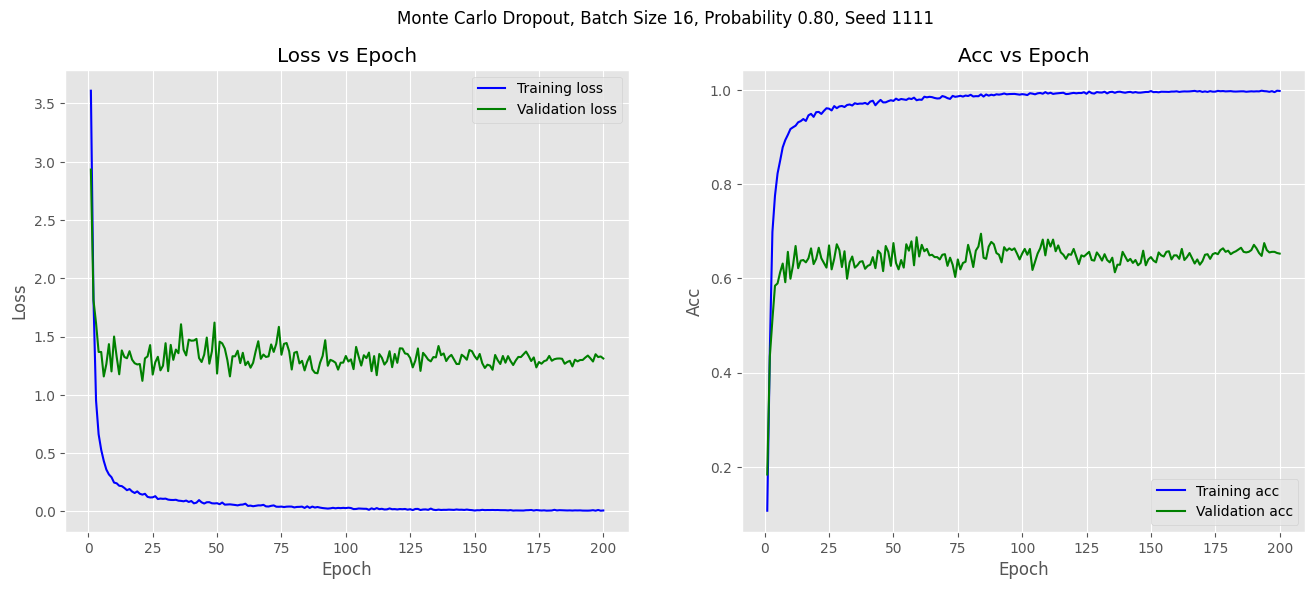

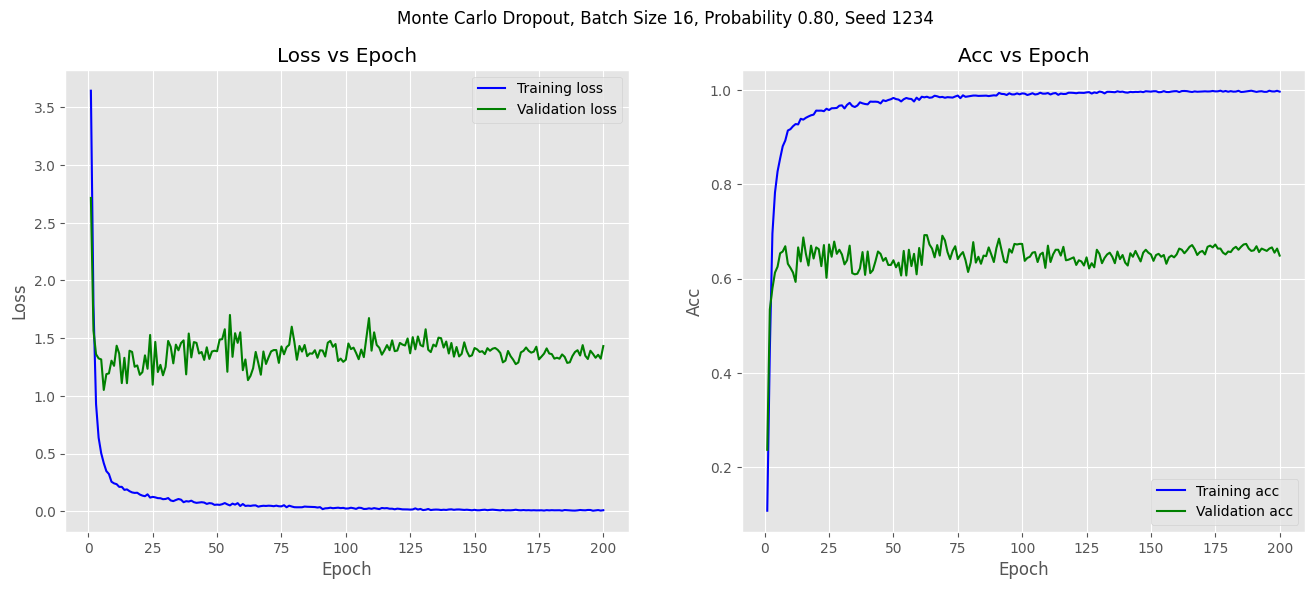

In [13]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Monte Carlo Dropout, Batch Size 16, Probability 0.80, Seed {seed}")
        plt.show()